# BRCA Mutation Status Classification from Nuclear Morphology
**Dataset:** TCGA ovarian cancer H&E tiles  
**Pipeline:** QC filtering → patient merging → StarDist2D segmentation → feature extraction → statistical testing → classification  
**Input:** BRCA_mut_intact_HE_tile_QC.csv, TCGA WSIs Clinical Data.csv  
**Output:** BRCA_cancer_only_features.csv

In [22]:

import os
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sn
from csbdeep.utils import normalize
from skimage import io
from skimage.color import rgb2gray
from skimage.io import imread
from skimage.measure import regionprops
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import LeaveOneOut
from sklearn.preprocessing import StandardScaler
from stardist.models import StarDist2D

## 1. Data Loading and Quality Control
Images and patient records are loaded from the provided spreadsheets. 
Only images passing both cell quality and stain quality checks are retained.
Patients with ambiguous BRCA status (NULL values) are excluded.

In [ ]:
images = pd.read_csv(r"C:\Users\qlptc\Downloads\BRCA_mut_intact_HE_tile_QC(Sheet1) (1).csv",sep=';')
print(images.head())

                                          image_name  \
0  TCGA-3P-A9WA-01Z-00-DX1.A5FDC436-7F0D-4DD2-864...   
1  TCGA-3P-A9WA-01Z-00-DX1.A5FDC436-7F0D-4DD2-864...   
2  TCGA-3P-A9WA-01Z-00-DX1.A5FDC436-7F0D-4DD2-864...   
3  TCGA-3P-A9WA-01Z-00-DX1.A5FDC436-7F0D-4DD2-864...   
4  TCGA-3P-A9WA-01Z-00-DX1.A5FDC436-7F0D-4DD2-864...   

   Adequate_CA_cell _Quality_1_0  Adequate_staining_quality_1_0  
0                              1                              1  
1                              1                              1  
2                              1                              1  
3                              1                              1  
4                              1                              1  


In [ ]:
patients = pd.read_csv(r"C:\Users\qlptc\Downloads\TCGA WSIs Clinical Data(Sheet1) (1).csv",sep=';')
adequate1 = images['Adequate_CA_cell _Quality_1_0'] == 1 
adequate2 = images['Adequate_staining_quality_1_0'] == 1
cleandata = images[adequate1 & adequate2]
print(repr(patients.columns.tolist()))

['Patient ID', 'BRCA status', 'HRD Scar Score', 'Diagnosis Age', 'Aneuploidy Score', 'Disease-specific Survival status', 'Fraction Genome Altered', 'MSI MANTIS Score', 'MSIsensor Score', 'Mutation Count', 'Overall Survival (Months)', 'Overall Survival Status', 'Disease-specific Survival status_1', 'Progress Free Survival (Months)', 'Progression Free Status', 'Tissue Source Site', 'Tissue Source Site Code', 'TMB (nonsynonymous)']


In [ ]:
relevant_patients = patients['BRCA status'].isnull()
Clean_patients = patients[~relevant_patients]
Clean_patients = Clean_patients.iloc[:,0:2]
Clean_patients["BRCA status"] = (Clean_patients['BRCA status'] != 'intact').astype(int)
Clean_patients
Clean_patients = Clean_patients.rename(columns={'Patient ID': 'Patient_ID'})


In [ ]:
cleandata['Patient_ID'] = cleandata['image_name'].str.split('-').str[:3].str.join('-')
merged_df = cleandata.merge(Clean_patients, on='Patient_ID')
print(f"Original: {len(cleandata)} | Merged: {len(merged_df)}")
merged_df.head()

Original: 1291 | Merged: 870


2983730505.py (1): 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


,image_name,Adequate_CA_cell _Quality_1_0,Adequate_staining_quality_1_0,Patient_ID,BRCA status
0,TCGA-3P-A9WA-01Z-00-DX1.A5FDC436-7F0D-4DD2-864...,1,1,TCGA-3P-A9WA,0
1,TCGA-3P-A9WA-01Z-00-DX1.A5FDC436-7F0D-4DD2-864...,1,1,TCGA-3P-A9WA,0
2,TCGA-3P-A9WA-01Z-00-DX1.A5FDC436-7F0D-4DD2-864...,1,1,TCGA-3P-A9WA,0
3,TCGA-3P-A9WA-01Z-00-DX1.A5FDC436-7F0D-4DD2-864...,1,1,TCGA-3P-A9WA,0
4,TCGA-3P-A9WA-01Z-00-DX1.A5FDC436-7F0D-4DD2-864...,1,1,TCGA-3P-A9WA,0


In [ ]:
Path_part = r"C:\Users\qlptc\OneDrive\Desktop\BRCA_mut_intact_HE_tile_QC\_HE_masks_"
base_path = Path(r"C:\Users\qlptc\OneDrive\Desktop\rak2\_HE_tiles_")
os.environ["KERAS_HOME"] = r"C:\Users\qlptc\OneDrive\Desktop\BRCA_mut_intact_HE_tile_QC\stardist\models"

(1024, 1024, 3) uint8


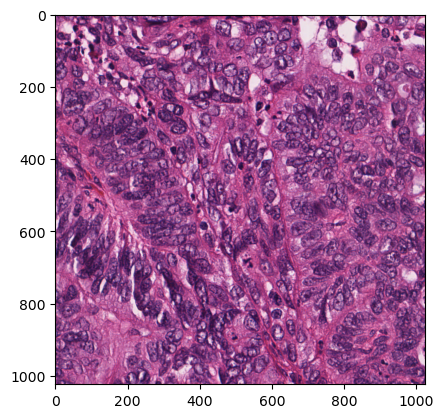

In [ ]:
from tkinter import image_names
from pathlib import Path
image_names = cleandata['image_name']
image_name = image_names.iloc[0]
img_path = base_path/image_name
image = imread(img_path)
plt.imshow(image)
print(image.shape , image.dtype)


## 2. Nucleus Segmentation and Feature Extraction
Each image is normalized per spatial axis and passed into the pretrained 
StarDist2D model (2D_versatile_he). Morphological features are extracted 
via regionprops for each detected nucleus. Only nuclei whose centroids 
fall within the expert-delineated cancer ROI are retained.

In [ ]:
model_stardist = StarDist2D.from_pretrained("2D_versatile_he")

features_list = []

for idx, row in merged_df.iterrows():
    img_name = row["image_name"]
    img_path = base_path / img_name

    if not img_path.exists():
        continue

    img = imread(str(img_path))

    # normalize per spatial axis (0,1) — required by StarDist input convention
    img_norm = normalize(img, axis=(0, 1))

    labels, _ = model_stardist.predict_instances(img_norm)

    props = regionprops(labels)
    for p in props:
        features_list.append(
            {
                "Patient_ID": row["Patient_ID"],
                "brca_status": row["BRCA status"],
                "area": p.area,
                "perimeter": p.perimeter,
                "eccentricity": p.eccentricity,
                "solidity": p.solidity,
                "major_axis": p.major_axis_length,
                "minor_axis": p.minor_axis_length,
                "extent": p.extent,
                # circularity is not a regionprops attribute — computed manually
                "circularity": (4 * np.pi * p.area) / (p.perimeter ** 2) if p.perimeter > 0 else 0,
            }
        )

df_features = pd.DataFrame(features_list)

Found model '2D_versatile_he' for 'StarDist2D'.
Loading network weights from 'weights_best.h5'.
Loading thresholds from 'thresholds.json'.
Using default values: prob_thresh=0.692478, nms_thresh=0.3.


KeyboardInterrupt: 

## 3. Statistical Testing
Features are aggregated to patient level (mean per patient across all nuclei).
Normality is assessed per group using Shapiro-Wilk. Levene's test determines 
variance homogeneity. Group comparison test is selected accordingly:
Student's t (normal, equal variance), Welch's t (normal, unequal variance), 
or Mann-Whitney U (non-normal).

Group 0 (Intact) count: 38
Group 1 (Mutated) count: 29
          Feature  Mean_Intact  Median_Intact  Std_Intact  Shapiro_p_Intact  Mean_Mutated  Median_Mutated  Std_Mutated  Shapiro_p_Mutated  Levene_p        Test_Used  p_value
        area_mean   758.598290     763.485180  135.213318          0.474811    720.693193      688.543766    95.550545           0.008099  0.113653   Mann-Whitney U 0.198991
   perimeter_mean   102.277157     102.947143    9.248266          0.524251     99.311808       96.840420     6.576283           0.008400  0.122262   Mann-Whitney U 0.158251
eccentricity_mean     0.681803       0.684076    0.025290          0.941561      0.666011        0.667032     0.029554           0.627888  0.705279 Student's t-test 0.021614
    solidity_mean     0.965201       0.965581    0.001785          0.165939      0.965607        0.966133     0.001693           0.168702  0.562473 Student's t-test 0.349357
  major_axis_mean    36.921588      37.487811    3.280095          0.358054

1419363682.py (67): 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

1419363682.py (69): set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
1419363682.py (74): 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

1419363682.py (76): set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.


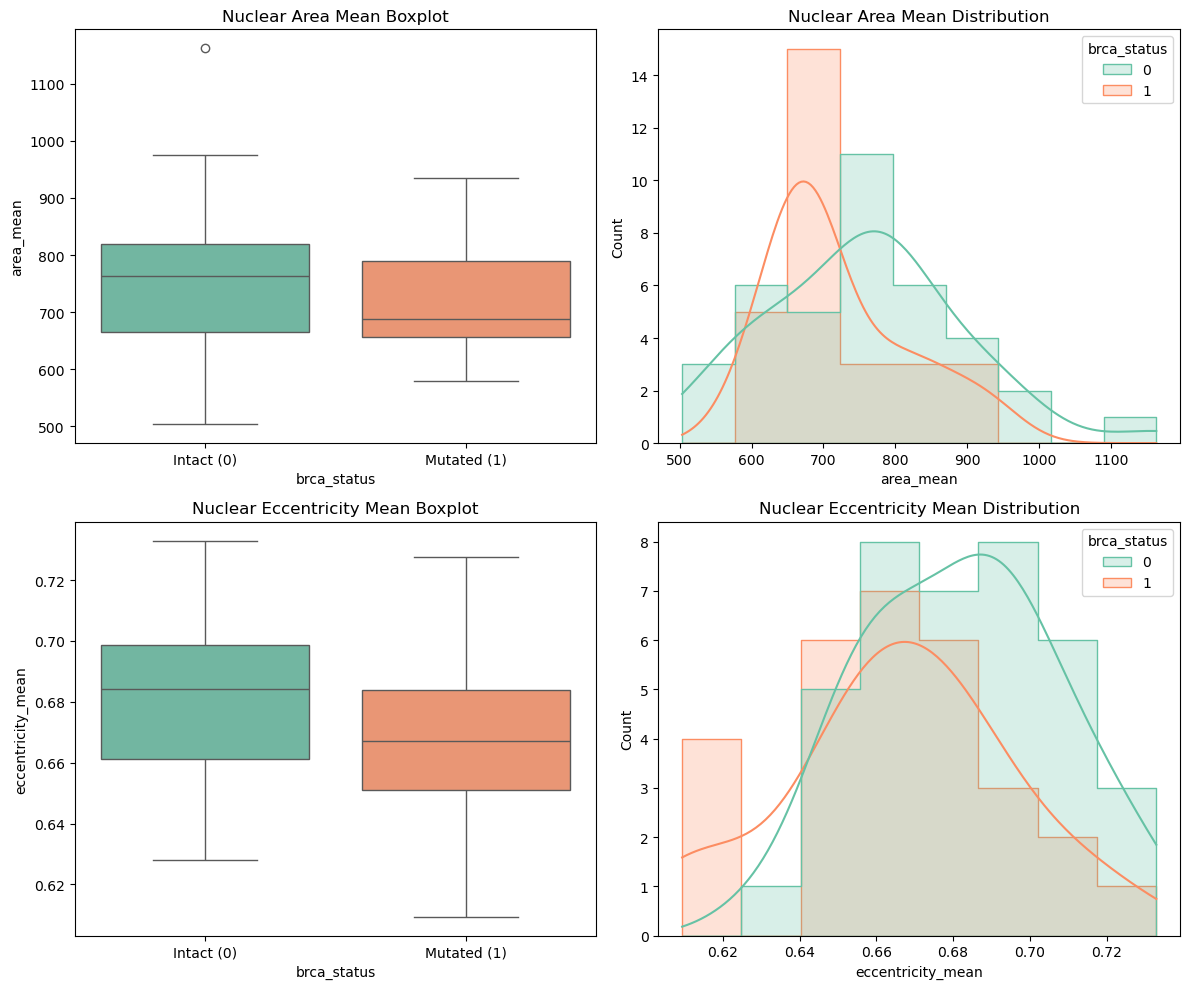

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sn

df = pd.read_csv("BRCA_cancer_only_features.csv")
df["Patient_ID"] = df["image_name"].str.split("-").str[:3].str.join("-")

morphology_cols = ["area", "perimeter", "eccentricity", "solidity", "major_axis", "minor_axis", "circularity"]
aggregation_dict = {col: ["mean", "std", "median"] for col in morphology_cols}
aggregation_dict["brca_status"] = "first"

patient_df = df.groupby("Patient_ID").agg(aggregation_dict)
patient_df.columns = [f"{col}_{stat}" if stat != "first" else col for col, stat in patient_df.columns]
patient_df = patient_df.reset_index()

# std is NaN for patients with a single image — filled with column median
if patient_df.isnull().sum().sum() > 0:
    patient_df = patient_df.fillna(patient_df.median(numeric_only=True))

g0 = patient_df[patient_df["brca_status"] == 0]
g1 = patient_df[patient_df["brca_status"] == 1]

print(f"Group 0 (Intact) count: {len(g0)}")
print(f"Group 1 (Mutated) count: {len(g1)}")

features_to_analyze = [f"{c}_mean" for c in morphology_cols]

results = []

for feat in features_to_analyze:
    m0, med0, std0 = g0[feat].mean(), g0[feat].median(), g0[feat].std()
    m1, med1, std1 = g1[feat].mean(), g1[feat].median(), g1[feat].std()

    w0, p_norm0 = stats.shapiro(g0[feat])
    w1, p_norm1 = stats.shapiro(g1[feat])

    stat_lev, p_lev = stats.levene(g0[feat], g1[feat])

    both_normal = (p_norm0 > 0.05) and (p_norm1 > 0.05)
    equal_var = (p_lev > 0.05)

    if both_normal:
        if equal_var:
            t_stat, p_val = stats.ttest_ind(g0[feat], g1[feat], equal_var=True)
            test_used = "Student's t-test"
        else:
            t_stat, p_val = stats.ttest_ind(g0[feat], g1[feat], equal_var=False)
            test_used = "Welch's t-test"
    else:
        t_stat, p_val = stats.mannwhitneyu(g0[feat], g1[feat], alternative='two-sided')
        test_used = "Mann-Whitney U"

    results.append({
        "Feature": feat,
        "Mean_Intact": m0, "Median_Intact": med0, "Std_Intact": std0, "Shapiro_p_Intact": p_norm0,
        "Mean_Mutated": m1, "Median_Mutated": med1, "Std_Mutated": std1, "Shapiro_p_Mutated": p_norm1,
        "Levene_p": p_lev, "Test_Used": test_used, "p_value": p_val
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

sn.boxplot(data=patient_df, x="brca_status", y="area_mean", ax=axes[0, 0], palette="Set2")
axes[0, 0].set_title("Nuclear Area Mean Boxplot")
axes[0, 0].set_xticklabels(["Intact (0)", "Mutated (1)"])

sn.histplot(data=patient_df, x="area_mean", hue="brca_status", kde=True, ax=axes[0, 1], palette="Set2", element="step")
axes[0, 1].set_title("Nuclear Area Mean Distribution")

sn.boxplot(data=patient_df, x="brca_status", y="eccentricity_mean", ax=axes[1, 0], palette="Set2")
axes[1, 0].set_title("Nuclear Eccentricity Mean Boxplot")
axes[1, 0].set_xticklabels(["Intact (0)", "Mutated (1)"])

sn.histplot(data=patient_df, x="eccentricity_mean", hue="brca_status", kde=True, ax=axes[1, 1], palette="Set2", element="step")
axes[1, 1].set_title("Nuclear Eccentricity Mean Distribution")

plt.tight_layout()
plt.savefig("descriptive_stats_plots.png")

In [38]:
import pandas as pd
from scipy import stats

df_features = pd.read_csv("BRCA_cancer_only_features.csv")
df_features["Patient_ID"] = (
    df_features["image_name"].str.split("-").str[:3].str.join("-")
)

morphology_cols = [
    "area",
    "perimeter",
    "eccentricity",
    "solidity",
    "major_axis",
    "minor_axis",
    "circularity",
]

patient_df = (
    df_features.groupby("Patient_ID")
    .agg({col: "mean" for col in morphology_cols})
    .reset_index()
)

patient_labels = (
    df_features.groupby("Patient_ID")["brca_status"].first().reset_index()
)
patient_df = patient_df.merge(patient_labels, on="Patient_ID")

group_intact = patient_df[patient_df["brca_status"] == 0]
group_mutated = patient_df[patient_df["brca_status"] == 1]



--- CLINICAL GROUP COMPARISON RESULTS ---
area            | Test: Mann-Whitney U   | p-value: 0.1990
perimeter       | Test: Mann-Whitney U   | p-value: 0.1583
eccentricity    | Test: Student's t-test | p-value: 0.0216
solidity        | Test: Student's t-test | p-value: 0.3494
major_axis      | Test: Mann-Whitney U   | p-value: 0.0775
minor_axis      | Test: Student's t-test | p-value: 0.5724


In [ ]:
import pandas as pd
from scipy import stats

df_features = pd.read_csv("BRCA_cancer_only_features.csv")
df_features["Patient_ID"] = (
    df_features["image_name"].str.split("-").str[:3].str.join("-")
)

morphology_cols = [
    "area",
    "perimeter",
    "eccentricity",
    "solidity",
    "major_axis",
    "minor_axis",
    "circularity",
]

patient_df = (
    df_features.groupby("Patient_ID")
    .agg({col: "mean" for col in morphology_cols})
    .reset_index()
)

patient_labels = (
    df_features.groupby("Patient_ID")["brca_status"].first().reset_index()
)
patient_df = patient_df.merge(patient_labels, on="Patient_ID")

group_intact = patient_df[patient_df["brca_status"] == 0]
group_mutated = patient_df[patient_df["brca_status"] == 1]

print("--- SHAPIRO-WILK NORMALITY TEST RESULTS ---")
print(f"{'Feature':<20} | {'Group':<10} | {'W-Statistic':<12} | {'p-value':<8}")
print("-" * 60)

for col in morphology_cols:
    w0, p0 = stats.shapiro(group_intact[col])
    print(f"{col:<20} | Intact (0) | {w0:<12.4f} | {p0:.4f}")
    w1, p1 = stats.shapiro(group_mutated[col])
    print(f"{col:<20} | Mutated(1) | {w1:<12.4f} | {p1:.4f}")
    print("-" * 60)

--- SHAPIRO-WILK NORMALITY TEST RESULTS ---
Feature              | Group      | W-Statistic  | p-value 
------------------------------------------------------------
area                 | Intact (0) | 0.9729       | 0.4748
area                 | Mutated(1) | 0.8965       | 0.0081
------------------------------------------------------------
perimeter            | Intact (0) | 0.9744       | 0.5243
perimeter            | Mutated(1) | 0.8972       | 0.0084
------------------------------------------------------------
eccentricity         | Intact (0) | 0.9875       | 0.9416
eccentricity         | Mutated(1) | 0.9725       | 0.6279
------------------------------------------------------------
solidity             | Intact (0) | 0.9582       | 0.1659
solidity             | Mutated(1) | 0.9486       | 0.1687
------------------------------------------------------------
major_axis           | Intact (0) | 0.9687       | 0.3581
major_axis           | Mutated(1) | 0.8949       | 0.0074
-----------

## 4. Classification — Leave-One-Out Cross-Validation
Only eccentricity (mean, std, median) is used as input — the sole feature 
showing statistically significant group difference (p=0.0216, Student's t-test).
Scaling is applied inside each fold to prevent data leakage.
Models compared: Logistic Regression, Random Forest.

In [ ]:
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.model_selection import LeaveOneOut
from sklearn.preprocessing import StandardScaler

# 1. Load the features file directly into memory
df_features = pd.read_csv("BRCA_cancer_only_features.csv")

# 2. Extract Patient IDs
df_features["Patient_ID"] = (
    df_features["image_name"].str.split("-").str[:3].str.join("-")
)

# 3. Comprehensive Patient-level Feature Aggregation
morphology_cols = [
    "area",
    "perimeter",
    "eccentricity",
    "solidity",
    "major_axis",
    "minor_axis",
    "circularity"
    
]

patient_df = (
    df_features.groupby("Patient_ID")
    .agg({col: ["mean", "std", "median"] for col in morphology_cols})
    .reset_index()
)

# Flatten MultiIndex columns
patient_df.columns = [
    f"{col}_{stat}" if stat != "" else col for col, stat in patient_df.columns
]

# 4. Attach patient labels back
patient_labels = (
    df_features.groupby("Patient_ID")["brca_status"].first().reset_index()
)
patient_df = patient_df.merge(patient_labels, on="Patient_ID")

# Fill missing values (std can be NaN if a patient only has 1 nucleus)
if patient_df.isnull().sum().sum() > 0:
    patient_df = patient_df.fillna(patient_df.median(numeric_only=True))

# 5. Define Feature Matrix (X) and Target Vector (y)
feature_cols = [c for c in patient_df.columns if c not in ["Patient_ID", "brca_status"]]
X = patient_df[feature_cols].values
y = patient_df["brca_status"].values

print(f"Features matrix shape: {X.shape} (Patients, Features)")
print(f"Class distribution: Intact={sum(y==0)}, Mutated={sum(y==1)}")
print("-" * 60)

# 6. Set up Leave-One-Out Cross-Validation (LOOCV)
loo = LeaveOneOut()

# Arrays to store the true labels and predicted labels for every single patient
y_true_all = []
y_pred_all = []
y_proba_all = []

print("Running Leave-One-Out Validation across all patients...")

# Loop through every single patient sample
for train_idx, test_idx in loo.split(X):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # Feature Normalization (Done inside the loop to avoid data leakage)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Initialize Decision Tree Classifier
    # max_depth is limited to prevent massive overfitting on patient-level data
    model = DecisionTreeClassifier(max_depth=3, random_state=42)
    model.fit(X_train_scaled, y_train)

    # Predict for the single left-out patient
    pred = model.predict(X_test_scaled)[0]
    proba = model.predict_proba(X_test_scaled)[0, 1]

    # Collect predictions
    y_true_all.append(y_test[0])
    y_pred_all.append(pred)
    y_proba_all.append(proba)

# Convert lists to numpy arrays for metric assessment
y_true_all = np.array(y_true_all)
y_pred_all = np.array(y_pred_all)

# 7. Print overall LOOCV model report
print("=" * 60)
print("FINAL LEAVE-ONE-OUT DECISION TREE PERFORMANCE REPORT")
print("=" * 60)

# Compute global metrics from collected predictions
final_acc = accuracy_score(y_true_all, y_pred_all)
tn, fp, fn, tp = confusion_matrix(y_true_all, y_pred_all).ravel()

sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

print(f"LOOCV Accuracy:                 {final_acc:.4f}")
print(f"LOOCV Sensitivity (Mutated TPR): {sensitivity:.4f}")
print(f"LOOCV Specificity (Intact TNR):  {specificity:.4f}")
print(f"Confusion Matrix:\n [{tn} {fp}]\n [{fn} {tp}]")
print("=" * 60)

Features matrix shape: (67, 21) (Patients, Features)
Class distribution: Intact=38, Mutated=29
------------------------------------------------------------
Running Leave-One-Out Validation across all patients...
FINAL LEAVE-ONE-OUT DECISION TREE PERFORMANCE REPORT
LOOCV Accuracy:                 0.7015
LOOCV Sensitivity (Mutated TPR): 0.5862
LOOCV Specificity (Intact TNR):  0.7895
Confusion Matrix:
 [30 8]
 [12 17]


## 5. Classification — 5-Fold Stratified Cross-Validation
Stratified splitting ensures class balance is preserved across folds.
Same feature set and scaling strategy as LOO.
Models compared: Logistic Regression, Decision Tree, Random Forest.

In [ ]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score

# 5-Fold Stratified Cross-Validation
# Using only eccentricity — the only feature showing statistically
# significant difference between BRCA-intact and BRCA-mutated groups (p=0.0216)
significant_features = ["eccentricity_mean", "eccentricity_std", "eccentricity_median"]
X_sig = patient_df[significant_features].values
y_sig = patient_df["brca_status"].values

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Containers for each model
lr_preds, lr_probas = [], []
dt_preds, dt_probas = [], []
rf_preds, rf_probas = [], []
y_true_5fold = []

print("Running 5-Fold Stratified Cross-Validation on significant features...")
print("-" * 60)

for fold, (train_idx, test_idx) in enumerate(skf.split(X_sig, y_sig), 1):
    X_train, X_test = X_sig[train_idx], X_sig[test_idx]
    y_train, y_test = y_sig[train_idx], y_sig[test_idx]

    # Normalize inside fold to prevent data leakage
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # 1. Logistic Regression
    lr = LogisticRegression(C=1.0, penalty="l2", random_state=42)
    lr.fit(X_train_scaled, y_train)
    lr_preds.extend(lr.predict(X_test_scaled))
    lr_probas.extend(lr.predict_proba(X_test_scaled)[:, 1])

    # 2. Decision Tree
    dt = DecisionTreeClassifier(max_depth=3, random_state=42)
    dt.fit(X_train_scaled, y_train)
    dt_preds.extend(dt.predict(X_test_scaled))
    dt_probas.extend(dt.predict_proba(X_test_scaled)[:, 1])

    # 3. Random Forest
    rf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
    rf.fit(X_train_scaled, y_train)
    rf_preds.extend(rf.predict(X_test_scaled))
    rf_probas.extend(rf.predict_proba(X_test_scaled)[:, 1])

    y_true_5fold.extend(y_test)
    print(f"Fold {fold} complete | Test patients: {len(test_idx)}")

y_true_5fold = np.array(y_true_5fold)

def report_metrics(name, y_true, y_pred, y_proba):
    acc = accuracy_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_proba)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    sens = tp / (tp + fn) if (tp + fn) > 0 else 0
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0
    print(f"{name:<22} | {acc:.4f}     | {auc:.4f}  | {sens:.4f}       | {spec:.4f}")

print("\n" + "=" * 70)
print("     FINAL 5-FOLD CROSS-VALIDATION PERFORMANCE REPORT")
print("     Features used: eccentricity (mean, std, median)")
print("=" * 70)
print(f"{'Model':<22} | {'Accuracy'} | {'AUC-ROC'} | {'Sensitivity'} | {'Specificity'}")
print("-" * 70)
report_metrics("Logistic Regression", y_true_5fold, lr_preds, lr_probas)
report_metrics("Decision Tree",       y_true_5fold, dt_preds, dt_probas)
report_metrics("Random Forest",       y_true_5fold, rf_preds, rf_probas)
print("=" * 70)

Running 5-Fold Stratified Cross-Validation on significant features...
------------------------------------------------------------
Fold 1 complete | Test patients: 14
Fold 2 complete | Test patients: 14
Fold 3 complete | Test patients: 13
Fold 4 complete | Test patients: 13
Fold 5 complete | Test patients: 13

     FINAL 5-FOLD CROSS-VALIDATION PERFORMANCE REPORT
     Features used: eccentricity (mean, std, median)
Model                  | Accuracy | AUC-ROC | Sensitivity | Specificity
----------------------------------------------------------------------
Logistic Regression    | 0.6567     | 0.6697  | 0.5172       | 0.7632
Decision Tree          | 0.5373     | 0.5186  | 0.3448       | 0.6842
Random Forest          | 0.5373     | 0.4723  | 0.4483       | 0.6053


In [37]:
from sklearn.metrics import confusion_matrix, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import LeaveOneOut
from sklearn.preprocessing import StandardScaler

# Using only eccentricity — the only feature showing statistically
# significant difference between BRCA-intact and BRCA-mutated groups (p=0.0216)
significant_features = ["eccentricity_mean", "eccentricity_std", "eccentricity_median"]
X_sig = patient_df[significant_features].values
y_sig = patient_df["brca_status"].values

loo = LeaveOneOut()

y_true = []
lr_preds, lr_probas = [], []
rf_preds, rf_probas = [], []

for train_idx, test_idx in loo.split(X_sig, y_sig):
    X_train, X_test = X_sig[train_idx], X_sig[test_idx]
    y_train, y_test = y_sig[train_idx], y_sig[test_idx]

    # Scaling inside fold to prevent data leakage
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    lr_model = LogisticRegression(C=1.0, penalty="l2", random_state=42)
    lr_model.fit(X_train_scaled, y_train)
    lr_preds.append(lr_model.predict(X_test_scaled)[0])
    lr_probas.append(lr_model.predict_proba(X_test_scaled)[:, 1][0])

    rf_model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
    rf_model.fit(X_train_scaled, y_train)
    rf_preds.append(rf_model.predict(X_test_scaled)[0])
    rf_probas.append(rf_model.predict_proba(X_test_scaled)[:, 1][0])

    y_true.append(y_test[0])

y_true = np.array(y_true)

lr_acc = accuracy_score(y_true, lr_preds)
lr_auc = roc_auc_score(y_true, lr_probas)
tn_lr, fp_lr, fn_lr, tp_lr = confusion_matrix(y_true, lr_preds).ravel()
lr_sens = tp_lr / (tp_lr + fn_lr) if (tp_lr + fn_lr) > 0 else 0
lr_spec = tn_lr / (tn_lr + fp_lr) if (tn_lr + fp_lr) > 0 else 0

rf_acc = accuracy_score(y_true, rf_preds)
rf_auc = roc_auc_score(y_true, rf_probas)
tn_rf, fp_rf, fn_rf, tp_rf = confusion_matrix(y_true, rf_preds).ravel()
rf_sens = tp_rf / (tp_rf + fn_rf) if (tp_rf + fn_rf) > 0 else 0
rf_spec = tn_rf / (tn_rf + fp_rf) if (tn_rf + fp_rf) > 0 else 0

print("=" * 60)
print("   LEAVE-ONE-OUT CROSS-VALIDATION PERFORMANCE REPORT")
print("   Features used: eccentricity (mean, std, median)")
print("=" * 60)
print(f"{'METRIC':<18} | {'LOGISTIC REGRESSION'} | {'RANDOM FOREST'}")
print("-" * 60)
print(f"{'Accuracy':<18} | {lr_acc:.4f}              | {rf_acc:.4f}")
print(f"{'AUC-ROC':<18} | {lr_auc:.4f}              | {rf_auc:.4f}")
print(f"{'Sensitivity (TPR)':<18} | {lr_sens:.4f}              | {rf_sens:.4f}")
print(f"{'Specificity (TNR)':<18} | {lr_spec:.4f}              | {rf_spec:.4f}")
print("=" * 60)

   LEAVE-ONE-OUT CROSS-VALIDATION PERFORMANCE REPORT
   Features used: eccentricity (mean, std, median)
METRIC             | LOGISTIC REGRESSION | RANDOM FOREST
------------------------------------------------------------
Accuracy           | 0.6269              | 0.5373
AUC-ROC            | 0.6534              | 0.4673
Sensitivity (TPR)  | 0.4483              | 0.4138
Specificity (TNR)  | 0.7632              | 0.6316
